# 01 – Data Exploration
**Purpose:** Load, inspect and clip any geodataset to a study area (AOI).
SWORD is the primary dataset. Additional datasets can be added in Section 2.

**Workflow:**
1.0 Imports

1.1 Configuration ← only edit this section

1.2 Load & inspect SWORD

1.3 Load & inspect additional datasets

1.4 Define AOI and clip all datasets

1.5 Save outputs

1.6 Interactive map

---
## 1.0 | Imports

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import fiona
import os
import sys
import webbrowser

sys.path.append(os.path.join("..", "src"))
from _0_config_paths import DATA_RAW, DATA_PROCESSED, DATA_OUTPUT

---
## 1.1 | Configuration
**Edit only this section.** All other cells run without changes.

In [2]:
# ============================================================
# 1.1 SWORD – primary dataset
# ============================================================
SWORD_PATH  = os.path.join(DATA_RAW, "0_data", "SWOT_river_database_SWORD", "as_sword_reaches_v17b.gpkg")
SWORD_LAYER = None   # set to layer name if GeoPackage has multiple layers, else None

# ============================================================
# 1.2 Additional datasets (add as many as needed)
# Each entry: (label, path, layer_or_None)
# ============================================================
ADDITIONAL_DATASETS = [
    # ("My second dataset", os.path.join(DATA_RAW, "path", "to", "file.gpkg"), None),
    # ("Geology",           os.path.join(DATA_RAW, "path", "to", "glim.gpkg"), None),
]

# ============================================================
# 1.3 Area of interest (AOI) – used to clip all datasets
# ============================================================
AOI_PATH        = os.path.join(DATA_RAW, "0_data", "Naryn_example", "Naryn_Basin.gpkg")
AOI_LAYER       = None   # set to layer name if multiple layers, else None
AOI_FILTER_COL  = None   # e.g. "basin_name" – filter by attribute, else None
AOI_FILTER_VAL  = None   # e.g. "Naryn"       – filter value, else None

# ============================================================
# 1.4 Outputs
# ============================================================
OUT_SWORD_CLIPPED = os.path.join(DATA_PROCESSED, "sword_naryn_clip.gpkg")
OUT_MAP           = os.path.join(DATA_OUTPUT,    "01_explore_map.html")

# ============================================================
print("Configuration set:")
print(f"  SWORD        : {SWORD_PATH}")
print(f"  AOI          : {AOI_PATH}")
print(f"  Output clip  : {OUT_SWORD_CLIPPED}")
print(f"  Output map   : {OUT_MAP}")

Configuration set:
  SWORD        : D:\0_InnoLab\0_data\SWOT_river_database_SWORD\as_sword_reaches_v17b.gpkg
  AOI          : D:\0_InnoLab\0_data\Naryn_example\Naryn_Basin.gpkg
  Output clip  : C:\Users\Duck\Documents\Studium\EAGLE\04_semester\0_InnoLab\RiverEggCode\data\processed\sword_naryn_clip.gpkg
  Output map   : C:\Users\Duck\Documents\Studium\EAGLE\04_semester\0_InnoLab\RiverEggCode\data\outputs\01_explore_map.html


Verify all files exist

In [3]:
check_paths = [("SWORD", SWORD_PATH), ("AOI", AOI_PATH)]
check_paths += [(label, path) for label, path, _ in ADDITIONAL_DATASETS]

all_ok = True
for label, path in check_paths:
    exists = os.path.exists(path)
    status = "Found" if exists else "NOT FOUND, check path in Section 1 (Configuration)"
    print(f"  {label:25s}: {status}")
    if not exists:
        all_ok = False

print()
print("All files found" if all_ok else "Fix missing paths in Section 1 before continuing.")

  SWORD                    : Found
  AOI                      : Found

All files found


---
## 1.2 | Load & inspect SWORD

In [4]:
# Inspect available layers
layers = fiona.listlayers(SWORD_PATH)
print(f"Layers in SWORD GeoPackage: {layers}")

# Load
layer = SWORD_LAYER if SWORD_LAYER else layers[0]
sword = gpd.read_file(SWORD_PATH, layer=layer)

print(f"\nReaches loaded : {len(sword)}")
print(f"CRS            : {sword.crs}")
print(f"Geometry type  : {sword.geom_type.unique()}")
print(f"Bounding box   : {sword.total_bounds}")

Layers in SWORD GeoPackage: ['reaches']

Reaches loaded : 100185
CRS            : EPSG:4326
Geometry type  : <StringArray>
['LineString']
Length: 1, dtype: str
Bounding box   : [-179.99998179    1.81712724  179.9999932    79.7441902 ]


In [5]:
# Column overview
print(f"Columns ({len(sword.columns)}):")
print(sword.columns.tolist())

Columns (37):
['x', 'y', 'reach_id', 'reach_len', 'n_nodes', 'wse', 'wse_var', 'width', 'width_var', 'facc', 'n_chan_max', 'n_chan_mod', 'obstr_type', 'grod_id', 'hfalls_id', 'slope', 'dist_out', 'lakeflag', 'max_width', 'n_rch_up', 'n_rch_dn', 'rch_id_up', 'rch_id_dn', 'swot_orbit', 'swot_obs', 'type', 'river_name', 'edit_flag', 'trib_flag', 'path_freq', 'path_order', 'path_segs', 'main_side', 'strm_order', 'end_reach', 'network', 'geometry']


In [6]:
# Exmple Key columns relevant for Egg Code
EGG_CODE_COLS = ["reach_id", "river_name", "width", "slope", "facc",
                 "n_chan_max", "n_chan_mod", "wse", "strm_order",
                 "obstr_type", "lakeflag", "dist_out"]

available = [c for c in EGG_CODE_COLS if c in sword.columns]
missing   = [c for c in EGG_CODE_COLS if c not in sword.columns]

print(f"Available Egg Code columns : {available}")
print(f"Missing (need other source): {missing}")

sword[available].describe()

Available Egg Code columns : ['reach_id', 'river_name', 'width', 'slope', 'facc', 'n_chan_max', 'n_chan_mod', 'wse', 'strm_order', 'obstr_type', 'lakeflag', 'dist_out']
Missing (need other source): []


,reach_id,width,slope,facc,n_chan_max,n_chan_mod,wse,strm_order,obstr_type,lakeflag,dist_out
count,1.001850e+05,100185.000000,100185.000000,1.001850e+05,100185.000000,100185.000000,100185.000000,100185.000000,100185.000000,100185.000000,1.001850e+05
mean,3.999485e+10,314.978048,3.475803,4.904656e+04,1.992264,1.091331,416.271638,-602.116554,0.244707,0.265479,1.368060e+06
std,5.477644e+09,1150.029371,81.728030,2.200395e+05,1.676883,0.543048,778.828568,2382.254680,0.756713,0.758776,1.272819e+06
min,3.110100e+10,-1.000000,0.000000,1.030913e+01,1.000000,1.000000,-157.000000,-9999.000000,0.000000,0.000000,3.154616e+01
25%,3.424660e+10,54.000000,0.032083,7.144127e+02,1.000000,1.000000,38.450001,1.000000,0.000000,0.000000,2.596927e+05
50%,4.326090e+10,84.000000,0.484670,2.354364e+03,1.000000,1.000000,166.200005,1.000000,0.000000,0.000000,1.016224e+06
75%,4.458110e+10,180.000000,2.157412,1.124937e+04,2.000000,1.000000,435.200012,2.000000,0.000000,0.000000,2.183873e+06
max,4.920700e+10,39404.277344,21601.316150,2.549429e+06,36.000000,27.000000,5551.350098,8.000000,4.000000,3.000000,6.262224e+06


In [7]:
# Missing values in key columns
print("Missing values per key column:")
sword[available].isnull().sum()

Missing values per key column:


reach_id      0
river_name    0
width         0
slope         0
facc          0
n_chan_max    0
n_chan_mod    0
wse           0
strm_order    0
obstr_type    0
lakeflag      0
dist_out      0
dtype: int64

---
## 1.3 | Load & inspect additional datasets
Add datasets in Section 1.2. This cell loops through all of them automatically.

In [8]:
# Dictionary to store all additional datasets: {label: GeoDataFrame}
extra_datasets = {}

if not ADDITIONAL_DATASETS:
    print("No additional datasets defined in Section 1.2 – skipping.")
else:
    for label, path, layer_name in ADDITIONAL_DATASETS:
        print(f"Loading: {label}")
        layers_available = fiona.listlayers(path)
        lyr = layer_name if layer_name else layers_available[0]
        gdf = gpd.read_file(path, layer=lyr)
        extra_datasets[label] = gdf

        print(f"  Features  : {len(gdf)}")
        print(f"  CRS       : {gdf.crs}")
        print(f"  Columns   : {gdf.columns.tolist()}")
        print()

No additional datasets defined in Section 1.2 – skipping.


---
## 1.4 | Define AOI and clip all datasets

In [9]:
# Load AOI
aoi_layers = fiona.listlayers(AOI_PATH)
aoi_layer  = AOI_LAYER if AOI_LAYER else aoi_layers[0]
aoi = gpd.read_file(AOI_PATH, layer=aoi_layer)

# Optional attribute filter
if AOI_FILTER_COL and AOI_FILTER_VAL:
    aoi = aoi[aoi[AOI_FILTER_COL] == AOI_FILTER_VAL]
    print(f"AOI filtered: {AOI_FILTER_COL} == {AOI_FILTER_VAL}")

print(f"AOI features : {len(aoi)}")
print(f"AOI CRS      : {aoi.crs}")

AOI features : 1
AOI CRS      : EPSG:4326


In [10]:
# Clip SWORD to AOI
if aoi.crs != sword.crs:
    aoi_sword = aoi.to_crs(sword.crs)
else:
    aoi_sword = aoi

sword_clipped = sword.clip(aoi_sword)

print(f"SWORD global  : {len(sword):>8} reaches")
print(f"SWORD in AOI  : {len(sword_clipped):>8} reaches")

SWORD global  :   100185 reaches
SWORD in AOI  :      140 reaches


In [11]:
# Clip additional datasets to AOI (loops automatically)
extra_clipped = {}

if not extra_datasets:
    print("No additional datasets to clip – skipping.")
else:
    for label, gdf in extra_datasets.items():
        aoi_matched = aoi.to_crs(gdf.crs) if aoi.crs != gdf.crs else aoi
        clipped = gdf.clip(aoi_matched)
        extra_clipped[label] = clipped
        print(f"{label}: {len(gdf)} → {len(clipped)} features after clip")

No additional datasets to clip – skipping.


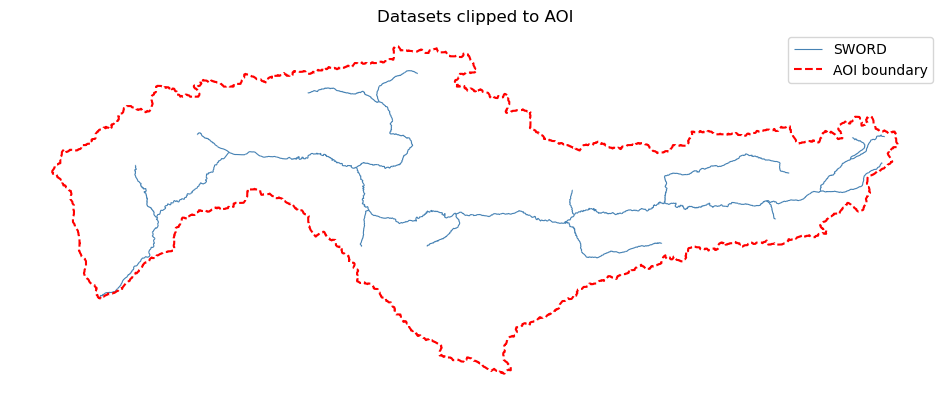

In [12]:
# Quick visual check
fig, ax = plt.subplots(figsize=(12, 8))
sword_clipped.plot(ax=ax, linewidth=0.8, color="steelblue", label="SWORD")
aoi.to_crs(sword.crs).boundary.plot(ax=ax, color="red", linewidth=1.5,
                                     linestyle="--", label="AOI boundary")

# Plot additional datasets if any
colors = ["green", "orange", "purple", "brown"]
for i, (label, gdf) in enumerate(extra_clipped.items()):
    gdf.to_crs(sword.crs).plot(ax=ax, linewidth=0.8,
                                color=colors[i % len(colors)], label=label)

plt.title("Datasets clipped to AOI")
plt.legend()
plt.axis("off")
plt.show()

---
## 1.5 | Save outputs

In [13]:
# Create output directories if they don't exist
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(DATA_OUTPUT, exist_ok=True)

# Save clipped SWORD
sword_clipped.to_file(OUT_SWORD_CLIPPED, driver="GPKG")
print(f"Saved SWORD clipped : {OUT_SWORD_CLIPPED}")

# Save additional clipped datasets
# Output filename = label in lowercase with underscores
for label, gdf in extra_clipped.items():
    safe_label = label.lower().replace(" ", "_")
    out = os.path.join(DATA_PROCESSED, f"{safe_label}_aoi_clip.gpkg")
    gdf.to_file(out, driver="GPKG")
    print(f"Saved {label:20s} : {out}")

Saved SWORD clipped : C:\Users\Duck\Documents\Studium\EAGLE\04_semester\0_InnoLab\RiverEggCode\data\processed\sword_naryn_clip.gpkg


---
## 1.6 | Interactive map

In [14]:
# Interactive map of clipped SWORD – saved as HTML and opened in browser
m = sword_clipped.explore(
    column="strm_order",
    cmap="Blues",
    tooltip=[c for c in ["reach_id", "river_name", "strm_order", "slope", "width"]
             if c in sword_clipped.columns],
    tiles="CartoDB positron",
    legend=True
)

m.save(OUT_MAP)
webbrowser.open(OUT_MAP)
print(f"Map saved and opened: {OUT_MAP}")

Map saved and opened: C:\Users\Duck\Documents\Studium\EAGLE\04_semester\0_InnoLab\RiverEggCode\data\outputs\01_explore_map.html
